#  Data Science Development: Final Presentation
Author: Bea Sauve   
Date: 03/2026   
Course: CSB304 H10 31429   
Instructor: Ix Procopios   

## Presentation Summary
This document serves as a tool used to break down and construct visualizaions on Team Limes' Earthquake presentation. Processes involed within this document may include but isn't limited to; data aggregations, statistical analyses, data refinement, and visualizations.

## Import Libraries

In [ ]:
# Call this function if libraries are not installed
# !pip install plotly


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px

## Import First Data Set

In [3]:
eq_95_23 = pd.read_csv("data/earthquake_1995-2023.csv")
eq_95_23.head(5)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


## Import Second Data Set

In [4]:
eq_data = pd.read_csv("data/earthquake_data.csv")

eq_data.head(5)

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 7.0 - 18 km SW of Malango, Solomon Islands",7.0,22-11-2022 02:03,8,7,green,1,768,us,117,0.509,17.0,mww,14.000,-9.7963,159.596,"Malango, Solomon Islands",Oceania,Solomon Islands
1,"M 6.9 - 204 km SW of Bengkulu, Indonesia",6.9,18-11-2022 13:37,4,4,green,0,735,us,99,2.229,34.0,mww,25.000,-4.9559,100.738,"Bengkulu, Indonesia",NaN,NaN
2,M 7.0 -,7.0,12-11-2022 07:09,3,3,green,1,755,us,147,3.125,18.0,mww,579.000,-20.0508,-178.346,NaN,Oceania,Fiji
3,"M 7.3 - 205 km ESE of Neiafu, Tonga",7.3,11-11-2022 10:48,5,5,green,1,833,us,149,1.865,21.0,mww,37.000,-19.2918,-172.129,"Neiafu, Tonga",NaN,NaN
4,M 6.6 -,6.6,09-11-2022 10:14,0,2,green,1,670,us,131,4.998,27.0,mww,624.464,-25.5948,178.278,NaN,NaN,NaN


## Combine Both Data Sets
Merge both data sets via concatination, then describe the dataset to determine if data type modifcations need to be made.

In [ ]:
merged_data = pd.concat([eq_95_23, eq_data], ignore_index=True)
merged_data.describe()
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1782 non-null   object 
 1   magnitude  1782 non-null   float64
 2   date_time  1782 non-null   object 
 3   cdi        1782 non-null   int64  
 4   mmi        1782 non-null   int64  
 5   alert      864 non-null    object 
 6   tsunami    1782 non-null   int64  
 7   sig        1782 non-null   int64  
 8   net        1782 non-null   object 
 9   nst        1782 non-null   int64  
 10  dmin       1782 non-null   float64
 11  gap        1782 non-null   float64
 12  magType    1782 non-null   object 
 13  depth      1782 non-null   float64
 14  latitude   1782 non-null   float64
 15  longitude  1782 non-null   float64
 16  location   1771 non-null   object 
 17  continent  490 non-null    object 
 18  country    1135 non-null   object 
dtypes: float64(6), int64(5), object(8)
memory usage:

## Check for missing values

In [6]:
merged_data.isna().sum()

title           0
magnitude       0
date_time       0
cdi             0
mmi             0
alert         918
tsunami         0
sig             0
net             0
nst             0
dmin            0
gap             0
magType         0
depth           0
latitude        0
longitude       0
location       11
continent    1292
country       647
dtype: int64

### Data Refinement: Alert Column
Calculate the averages of earthquake defining factors to determine a correlation between alert type and values. Based on the summary, we will apply conditional statements to fill the N/A columns of Alert with colors correlated alert color of the data described.

Aggregate columns, and look at the averages of earthquake data to determine correlations between data and alert type

In [8]:

cols = ['sig', 'cdi', 'mmi', 'depth', 'magnitude', 'dmin','gap','tsunami']
merged_data[merged_data['alert'].notna()].groupby('alert')[cols].mean()

,sig,cdi,mmi,depth,magnitude,dmin,gap,tsunami
alert,,,,,,,,
green,773.946903,4.420354,5.231563,117.384211,6.858112,2.661566,26.079027,0.740413
orange,1377.913043,8.391304,7.913043,40.145696,7.123913,1.974587,19.673913,0.500000
red,2492.400000,8.280000,8.280000,18.524760,7.304000,1.452416,41.328000,0.400000
yellow,1039.756522,7.634783,7.130435,44.997904,7.046087,1.854777,32.046957,0.721739


Modify alert names based on average sig levels and mmi

In [ ]:
def rename_alert(row):
    if row['alert'] is not np.nan:
        return row['alert']

    sig = row['sig']
    mmi = row['mmi']

    # Primary: sig level
    if sig >= 1800:
        alert = 'red'
    elif sig >= 1200:
        alert = 'orange'
    elif sig >= 900:
        alert = 'yellow'
    else:
        alert = 'green'

    # Secondary check: bump up if mmi is high but sig is borderline
    if mmi >= 8.0 and alert == 'yellow':
        alert = 'orange'

    # Hard rule: tsunami overrides everything
    if row['tsunami'] == 1 and alert in ['green', 'yellow']:
        alert = 'orange'

    return alert

merged_data['alert'] = merged_data.apply(rename_alert, axis=1)

# Verify distribution looks reasonable
print(merged_data['alert'].value_counts())

alert
green     1384
yellow     221
orange     146
red         31
Name: count, dtype: int64


# Map making
This map shows all earthquake locations

In [42]:
# use merged data, lat, lon, and size by sig level
fig = px.density_map(merged_data, lat='latitude', lon='longitude', z = 'sig', radius = 15,
# Set map location, style, and plot size
center = dict(lat = 0, lon = 180), zoom=0, map_style="open-street-map", width= 900, height = 500)
fig.show()

We can note a higher concentration of significant earthquake levels around Asia and South America.

## Determine alert levels by region


In [ ]:
import plotly.express as px
# observe occurances within each continent to determine appropriate chart.
merged_data['continent'].value_counts()

# Create pivot table
levels = merged_data.groupby(['continent', 'alert']).size().reset_index(name='count')
# Only use colors for columns that exist in data
fig = px.bar(levels,
             x='continent',
             y='count',
             color='alert',
             barmode='stack',
             color_discrete_map={
                 'green': 'darkolivegreen',
                 'yellow': 'goldenrod',
                 'orange': 'chocolate',
                 'red': 'firebrick'
             },
             # Organize the order each alert is displayed
             category_orders={'alert': ['green', 'yellow', 'orange', 'red']}, 
             title='Earthquake Alert Levels by Region')
# Adjust the plot size  
fig.update_layout(width=1200, height=600,
                  plot_bgcolor = 'white')        
fig.show()


We can note with this chart that Asia has a significantly high number of earthquakes compared to all other countries. South America has the second highest count of earthquakes. A large majority of each regions earthquake types are a green alert. This chart also supports the above map in identifying the regions with higher leveled earthquakes

# Scatter of CDI vs MMI
How does intrumental decetion compare to citizen detection levels


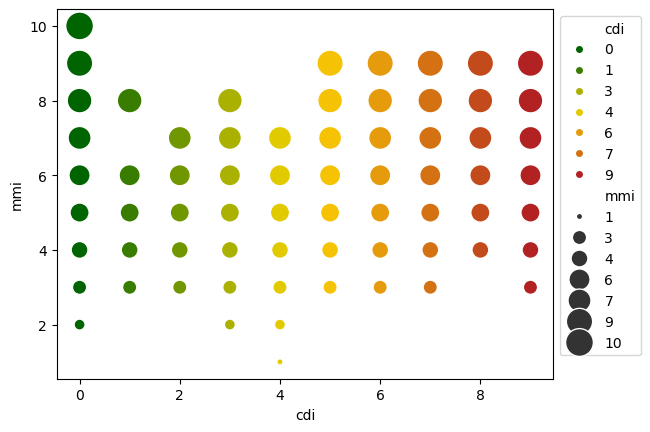

In [66]:
# Create a custom Color palette
custom_cmap = sns.blend_palette(["darkgreen","gold", "firebrick"], as_cmap=True)
# Scatterplot of cdi vs mmi, color set by cdi, size set by mmi
cm_plot = sns.scatterplot(data = merged_data, x = "cdi", y = "mmi",          # Data
                hue = 'cdi', palette= custom_cmap,                 # Colors
                size = 'mmi', sizes = (20,400))   # Size
sns.move_legend(cm_plot, "upper left", bbox_to_anchor=(1, 1))
plt.show()

# References
This section serves as a references as to where I obtained information to assist in the development of my visualizations

* Density map
    * https://plotly.com/python/density-heatmaps/

* Stacked chart:
    * Plotly Graphing: https://plotly.com/python/plotly-express/
    * plot colors : https://www.tutorialspoint.com/matplotlib/matplotlib_background_colors.htm#:~:text=By%20default%20it's%20often%20white,set_facecolor('color_name').
    * python colors: https://i.sstatic.net/lFZum.

* Scatter plot:
    * Seaborn Scatterplot : https://seaborn.pydata.org/generated/seaborn.scatterplot.html